# PyPAS Transport Solver — Analytical Benchmark

This notebook validates `profile_solver` against two independent analytical results.

## Why validation matters

`profile_solver` uses a finite-difference (FD) discretisation of the 1D positron transport equation. The solver is second-order accurate (O(Δz²)), but without an independent check the accuracy claim is unverifiable. Two complementary benchmarks are presented here:

1. **Surface annihilation fraction** — for a semi-infinite homogeneous medium,    the exact surface fraction is given by a closed-form integral transform of the    implantation profile. This tests the boundary condition and the annihilation    fraction computation for realistic (Makhov) profiles.

2. **Full positron profile** — for a homogeneous medium with constant D, drift    velocity v = μE, and annihilation rate λ, the exact solution is:
   $$c(z) = A\,e^{r_-z} + P\,e^{-z/L_\mathrm{impl}}$$
   where $r_-$ and the constants $A$, $P$ are known analytically from the    coefficients. This tests the interior FD scheme, the drift term, and the    convergence rate.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from pyPAS.transport import (
    makhov_material_parameters, makhov_profile,
    multilayer_implantation_profile, profile_solver,
)
from pyPAS.model import Material, Layer, Sample
from pyPAS.analysis import compute_annihilation_fractions

## 1. Surface annihilation fraction benchmark

For a **semi-infinite homogeneous medium** the probability that a positron implanted at depth $z_0$ eventually reaches the surface is $e^{-z_0/L} / (1 + L_a/L)$, where $L = \sqrt{D/\lambda}$ is the diffusion length and $L_a$ is the surface absorption length. The total surface fraction follows from integrating over the implantation profile $I(z)$:

$$f_\mathrm{surface} = \frac{1}{1 + L_a/L} \int_0^\infty I(z)\,e^{-z/L}\,dz$$

This is an exact result for a homogeneous semi-infinite medium.

In [2]:
D   = 1.0    # nm²/ps (normalised)
L_a = 5.0   # nm — surface absorption length
sample_length = 1000.0  # nm

Cu_params = makhov_material_parameters().iloc[9].copy()
Cu_params['density'] = 8.96   # g/cm³

depth = np.linspace(0, sample_length, 20_000)

energies    = [2.0, 5.0, 10.0, 15.0]   # keV
diff_lengths = [50, 100, 200]           # nm

rows = []
for L_diff in diff_lengths:
    lam   = D / L_diff**2
    layer = Layer(width=sample_length,
                  material=Material(diffusion=D, mobility=0, bulk_annihilation_rate=lam))
    sample = Sample(layers=[layer], absorption_length=L_a)

    for e in energies:
        # Makhov implantation profile
        prof = multilayer_implantation_profile(
            e, depth, [sample_length], [Cu_params],
            [Cu_params['density']], makhov_profile)
        x, y = prof.coords['x'].values, prof.values

        # Numerical surface fraction
        ann   = profile_solver(prof, sample)
        f_num = float(compute_annihilation_fractions(ann, sample).sel(layer=-1))

        # Analytical surface fraction (exact integral transform)
        f_analytic = float(np.trapezoid(y * np.exp(-x / L_diff), x)) / (1 + L_a / L_diff)

        rows.append({'L [nm]': L_diff, 'E [keV]': e,
                     'f_numeric': f_num, 'f_analytic': f_analytic,
                     'error [%]': 100 * abs(f_num - f_analytic) / f_analytic})

import pandas as pd
df = pd.DataFrame(rows)
print(df.to_string(index=False, float_format='{:.4f}'.format))

 L [nm]  E [keV]  f_numeric  f_analytic  error [%]
     50   2.0000     0.7484      0.7483     0.0052
     50   5.0000     0.4100      0.4100     0.0003
     50  10.0000     0.1310      0.1310     0.0022
     50  15.0000     0.0500      0.0500     0.1479
    100   2.0000     0.8626      0.8626     0.0066
    100   5.0000     0.6204      0.6204     0.0031
    100  10.0000     0.2966      0.2966     0.0151
    100  15.0000     0.1409      0.1403     0.4025
    200   2.0000     0.9286      0.9280     0.0560
    200   5.0000     0.7821      0.7807     0.1741
    200  10.0000     0.5119      0.5087     0.6221
    200  15.0000     0.3157      0.3086     2.2831


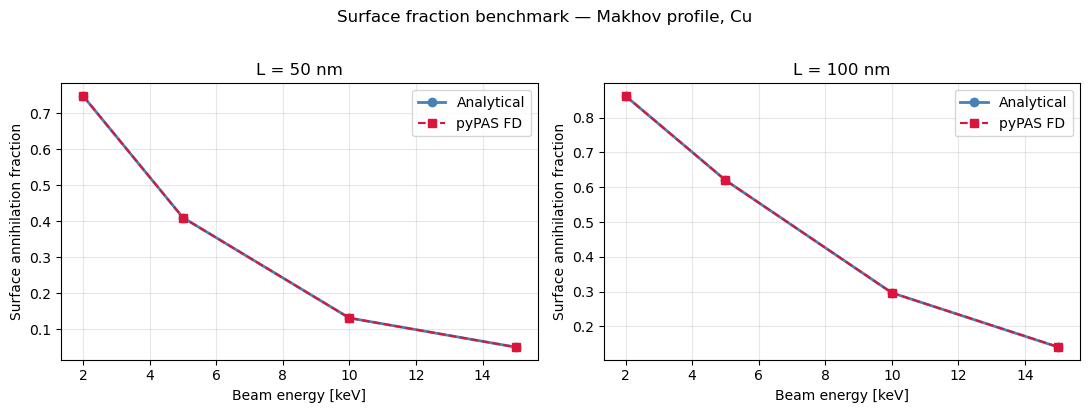

Relative error (%) between analytical formula and pyPAS FD solver:
E [keV]    2.0     5.0     10.0    15.0
L [nm]                                 
50      0.0052% 0.0003% 0.0022% 0.1479%
100     0.0066% 0.0031% 0.0151% 0.4025%
200     0.0560% 0.1741% 0.6221% 2.2831%


In [3]:
# Plot: numerical vs analytical for each L
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, L_diff in zip(axes, [50, 100]):
    sub = df[df['L [nm]'] == L_diff]
    ax.plot(sub['E [keV]'], sub['f_analytic'], 'o-', color='steelblue',
            lw=2, markersize=6, label='Analytical')
    ax.plot(sub['E [keV]'], sub['f_numeric'],  's--', color='crimson',
            lw=1.5, markersize=6, label='pyPAS FD')
    ax.set_title(f'L = {L_diff} nm')
    ax.set_xlabel('Beam energy [keV]')
    ax.set_ylabel('Surface annihilation fraction')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Surface fraction benchmark — Makhov profile, Cu', y=1.02)
plt.tight_layout()
plt.show()

# Error table
print('Relative error (%) between analytical formula and pyPAS FD solver:')
pivot = df.pivot(index='L [nm]', columns='E [keV]', values='error [%]')
print(pivot.to_string(float_format='{:.4f}%'.format))

## 2. Full profile benchmark

For **constant coefficients** (D, drift velocity v = μE, annihilation rate λ) and an exponential source $I(z) = (I_0/L_\mathrm{impl})\,e^{-z/L_\mathrm{impl}}$, the transport equation

$$D\,c'' - v\,c' - \lambda\,c = -I(z)$$

has an exact closed-form solution. With the decaying homogeneous mode $r_- = (v - \sqrt{v^2 + 4D\lambda})/(2D)$ and the particular solution coefficient $P = -I_0/(D/L_\mathrm{impl}^2 + v/L_\mathrm{impl} - \lambda)$, the complete solution satisfying the radiative BC $Dc'(0) = (D/L_a)\,c(0)$ is:

$$c(z) = A\,e^{r_-z} + P\,e^{-z/L_\mathrm{impl}}, \quad A = \frac{P(1/L_\mathrm{impl} + 1/L_a)}{r_- - 1/L_a}$$

The FD solver is compared to this formula for several mesh resolutions. The relative error should decrease as $O(\Delta z^2)$, confirming second-order accuracy of the scheme.

In [4]:
# ── Benchmark parameters ─────────────────────────────────────────────────────
D      = 1.0      # nm²/ps
v      = 0.05     # nm/ps  (drift = μ × E)
lam    = 1/50**2  # 1/ps   (bulk diffusion length L = 50 nm)
L_a    = 5.0      # nm
L_impl = 30.0     # nm  (implantation depth scale)
I0     = 1/L_impl # normalised source amplitude
mobility = 0.5    # nm²/(ps·V)
E_field  = v / mobility  # V/nm

sample_length = 1000.0  # nm
# ─────────────────────────────────────────────────────────────────────────────

# Analytical solution
r_minus = (v - np.sqrt(v**2 + 4*D*lam)) / (2*D)
P       = -I0 / (D/L_impl**2 + v/L_impl - lam)
A_coef  = P * (1/L_impl + 1/L_a) / (r_minus - 1/L_a)

def c_analytical(z):
    return A_coef * np.exp(r_minus * z) + P * np.exp(-z / L_impl)

print(f'r₋ = {r_minus:.5f} nm⁻¹  →  effective L_eff = {-1/r_minus:.1f} nm')
print(f'P = {P:.4f},  A = {A_coef:.4f}')
print(f'c(0) analytical = {c_analytical(0):.6f}')

r₋ = -0.00702 nm⁻¹  →  effective L_eff = 142.5 nm
P = -14.0187,  A = 15.8009
c(0) analytical = 1.782184


In [5]:
# ── FD solver at high mesh resolution ────────────────────────────────────────
mesh_size = 100_000

layer  = Layer(width=sample_length,
               material=Material(diffusion=D, mobility=mobility,
                                  bulk_annihilation_rate=lam))
sample = Sample(layers=[layer], absorption_length=L_a)

mesh_pts  = np.linspace(0, sample_length, mesh_size)
# Exponential source (normalised so integral = 1)
source_vals = I0 * np.exp(-mesh_pts[:-1] / L_impl)
source = xr.DataArray(source_vals / float(np.trapezoid(source_vals, mesh_pts[:-1])),
                      coords={'x': mesh_pts[:-1]})
e_field = xr.DataArray(np.full(len(mesh_pts), E_field), coords={'x': mesh_pts})

c_num = profile_solver(source, sample, electric_field=e_field, mesh_size=mesh_size)
z_fd  = c_num.coords['x'].values
c_ref = c_analytical(z_fd)

print(f'c(0) numerical  = {c_num.values[0]:.6f}')
print(f'c(0) analytical = {c_analytical(0):.6f}')

# Relative error (only where |c| > 1% of peak)
threshold = 0.01 * c_ref.max()
mask      = c_ref > threshold
rel_err   = np.abs(c_num.values - c_ref) / np.abs(c_ref)
print(f'Max relative error (c > 1% peak): {rel_err[mask].max():.2e}')
print(f'Mean relative error:              {rel_err[mask].mean():.2e}')

c(0) numerical  = 1.782184
c(0) analytical = 1.782184
Max relative error (c > 1% peak): 5.66e-08
Mean relative error:              3.05e-08


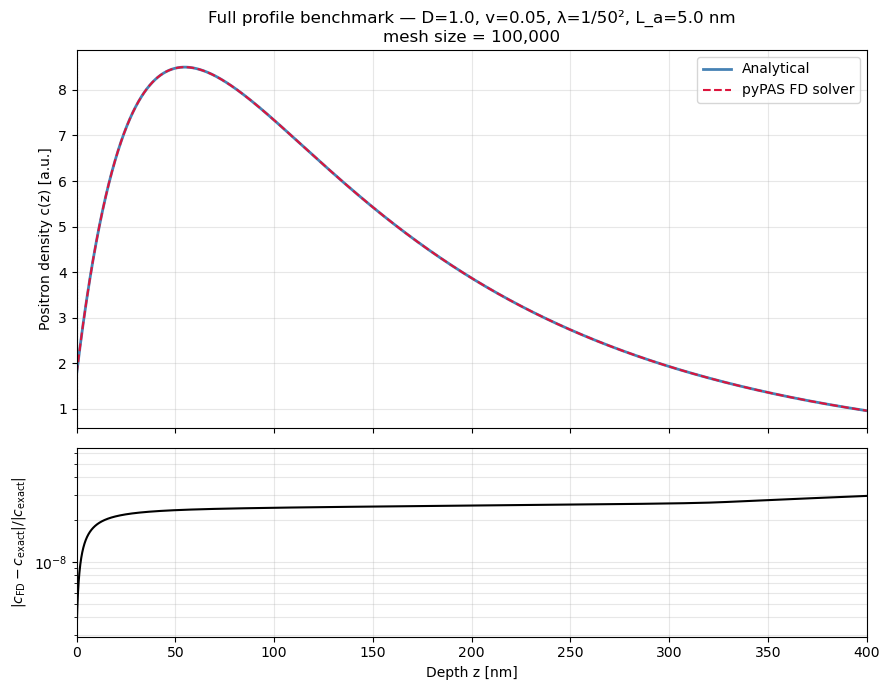

In [6]:
# Two-panel figure matching the paper's Figure 4 layout
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})

# Top: profiles
z_plot = z_fd[z_fd <= 400]
ax1.plot(z_plot, c_analytical(z_plot), '-',  color='steelblue', lw=2,   label='Analytical')
ax1.plot(z_plot, c_num.values[:len(z_plot)], '--', color='crimson',  lw=1.5, label='pyPAS FD solver')
ax1.axvline(0, color='gray', lw=0.8, ls=':')
ax1.set_ylabel('Positron density c(z) [a.u.]')
ax1.set_title(f'Full profile benchmark — D={D}, v={v}, λ=1/{int(1/lam**0.5)}², '
              f'L_a={L_a} nm\nmesh size = {mesh_size:,}')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bottom: relative error
ax2.semilogy(z_fd[mask], rel_err[mask], color='black', lw=1.5)
ax2.set_ylabel(r'$|c_\mathrm{FD} - c_\mathrm{exact}| / |c_\mathrm{exact}|$')
ax2.set_xlabel('Depth z [nm]')
ax2.set_xlim(0, 400)
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

## 3. Convergence with mesh size

The FD scheme is second-order accurate: the relative error should scale as $O(\Delta z^2) = O(1/N^2)$ where $N$ is the number of mesh cells. A log–log plot of the error vs $N$ with slope −2 confirms this.

N =   1,000  max rel error = 2.33e-04
N =   3,000  max rel error = 2.58e-05
N =  10,000  max rel error = 2.32e-06
N =  30,000  max rel error = 2.58e-07
N = 100,000  max rel error = 5.66e-08


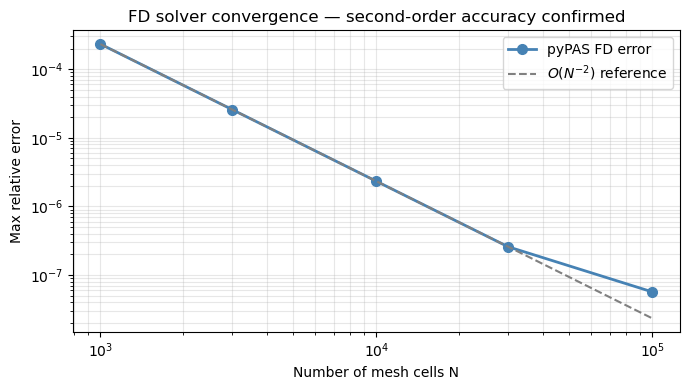

In [7]:
# ── This cell takes about 1–2 minutes ────────────────────────────────────────
mesh_sizes = [1_000, 3_000, 10_000, 30_000, 100_000]
max_errors = []

for N in mesh_sizes:
    mpts = np.linspace(0, sample_length, N)
    src_v = I0 * np.exp(-mpts[:-1] / L_impl)
    src   = xr.DataArray(src_v / float(np.trapezoid(src_v, mpts[:-1])),
                         coords={'x': mpts[:-1]})
    ef    = xr.DataArray(np.full(len(mpts), E_field), coords={'x': mpts})
    c     = profile_solver(src, sample, electric_field=ef, mesh_size=N)

    z_    = c.coords['x'].values
    c_ex  = c_analytical(z_)
    thresh = 0.01 * c_ex.max()
    rel   = np.abs(c.values - c_ex) / np.abs(c_ex)
    max_errors.append(rel[c_ex > thresh].max())
    print(f'N = {N:>7,}  max rel error = {max_errors[-1]:.2e}')
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(mesh_sizes, max_errors, 'o-', color='steelblue', lw=2, markersize=7,
          label='pyPAS FD error')

# Reference O(1/N²) line
N_ref = np.array([mesh_sizes[0], mesh_sizes[-1]], dtype=float)
ax.loglog(N_ref, max_errors[0] * (N_ref[0]/N_ref)**2, '--', color='gray',
          label=r'$O(N^{-2})$ reference')

ax.set_xlabel('Number of mesh cells N')
ax.set_ylabel('Max relative error')
ax.set_title('FD solver convergence — second-order accuracy confirmed')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()